# Quads design (3dp pla + blue shims) for multiloading source cloaking


## Imports

In [ ]:
import os

os.environ["XLA_FLAGS"] = (
    "--xla_force_host_platform_device_count=8"  # Use 8 CPU cores for JAX pmap
)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors
import jax
import jax.numpy as jnp
import pandas as pd
from pathlib import Path
from problems.quads_dynamic_load_shielding_source_multi_loading import (
    ForwardInput,
    ForwardProblem,
    OptimizationProblem,
)
from mechanicalmetamaterialcloaks.utils import save_data, load_data, SolutionData
from mechanicalmetamaterialcloaks.plotting import plot_geometry, generate_several_animations
from typing import Optional, List, Tuple
from jax import random

jax.config.update("jax_enable_x64", True)  # enable float64 type

import time

plt.style.use(["science", "grid"])
%matplotlib widget

## Plotting functions


In [2]:
def plot_objective_iterations(
    optimization: OptimizationProblem,
    optimization_filename: Optional[str] = None,
    figsize=(10, 9),
    fontsize=14,
    ticksize=12,
    linewidth=3,
    markersize=5,
    xlim=None,
    ylim=None,
):
    fig, axes = plt.subplots(figsize=figsize, sharex=True, constrained_layout=True)
    axes.plot(
        jnp.array(optimization.objective_values)
        / optimization.forward_problem.n_timepoints,
        lw=linewidth,
        color="#16a085",
        label="Total objective",
        zorder=10,
        marker="o",
        markersize=markersize,
    )
    colors = ["#d35400", "#e67e22", "#f39c12", "#f1c40f"]

    # for k in range(len(optimization.objective_values_individual[0])):
    #     axes.plot([optimization.objective_values_individual[i][k]/optimization.forward_problem.n_timepoints for i in range(len(optimization.objective_values_individual))],
    #               lw=2,
    #               color=colors[k],
    #               label=f"Loading direction {k+1}",
    #               linestyle='--')
    axes.axhline(y=0, color="black")
    axes.axvline(x=0, color="black")
    axes.set_ylabel(r"Objective $J$ [-]", fontsize=fontsize)
    axes.set_xlabel(r"Iteration \#", fontsize=fontsize)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    axes.tick_params(labelsize=ticksize)
    # Make spine 1pt width
    for spine in axes.spines.values():
        spine.set_linewidth(1)
    axes.grid(False)
    # axes.legend()

    if optimization_filename is not None:
        path = Path(
            f"../out/{optimization.name}/{optimization_filename}/objective_iterations.png"
        )
        # Make sure parents directories exist
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(path), dpi=300)
    return fig, axes


def plot_objective_and_constraints_iterations(
    optimization: OptimizationProblem,
    optimization_filename: Optional[str] = None,
    figsize=(10, 9),
):
    fig, axes = plt.subplots(
        nrows=3, figsize=figsize, sharex=True, constrained_layout=True
    )
    axes[0].set(ylabel="Objective")
    axes[0].plot(
        optimization.objective_values, lw=3, color="#2980b9", label="Total objective"
    )
    colors = ["#d35400", "#e67e22", "#f39c12", "#f1c40f"]

    for k in range(len(optimization.objective_values_individual[0])):
        axes[0].plot(
            [
                optimization.objective_values_individual[i][k]
                for i in range(len(optimization.objective_values_individual))
            ],
            lw=3,
            color=colors[k],
            label=f"Loading direction {k + 1}",
            linestyle="--",
        )
    axes[0].legend()
    axes[1].set(ylabel="Angle constraints violation")
    axes[1].plot(optimization.constraints_violation["angles"], lw=3, color="#c0392b")
    axes[1].axhline(y=0, color="black")
    axes[2].set(ylabel="Edge length constraints violation")
    axes[2].plot(
        optimization.constraints_violation["edge_lengths"], lw=3, color="#c0392b"
    )
    axes[2].axhline(y=0, color="black")
    axes[-1].set(xlabel=r"Iteration \#")

    if optimization_filename is not None:
        path = Path(
            f"../out/{optimization.name}/{optimization_filename}/objective_and_constraints_iterations.png"
        )
        # Make sure parents directories exist
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(path), dpi=300)
    return fig, axes


def compute_individual_objective(
    solution_data: SolutionData, optimization: OptimizationProblem
):
    dimension_less = jnp.array(
        [
            1 / optimization.forward_problem.cloaked_geometry.spacing,
            1 / optimization.forward_problem.cloaked_geometry.spacing,
            1,
        ]
    )
    return (
        (
            solution_data.fields[
                :, 0, optimization.forward_problem.mgIDs_surronding_area, :
            ]
            * dimension_less
        )
        ** 2
    ).sum()


def delta_function_integrated(solution_data, spacing, mgIDs_surronding_area):
    dimension_less = jnp.array([1 / spacing, 1 / spacing, 1])
    return (
        (
            ((solution_data.fields[:, 0, mgIDs_surronding_area, :]) * dimension_less)
            ** 2
        ).sum(axis=(1, 2))
    ) ** 0.5


def generate_delta_difference_column(
    solution_data: List[SolutionData],
    mgIDs_surronding_area: jnp.ndarray,
    spacing: float,
    title: str,
    out_filename,
    solution_data_opcg: List[SolutionData] = None,
    sub_title: List = None,
    figsize=(12, 12),
):
    # plot
    fig, ax = plt.subplots(len(solution_data), figsize=figsize, constrained_layout=True)
    label = "initial guess" if solution_data_opcg != None else ""
    for k, sol_data in enumerate(solution_data):
        delta_value = delta_function_integrated(
            sol_data, spacing, mgIDs_surronding_area
        )
        timepoints = sol_data.timepoints
        if sub_title != None:
            ax[k].set_title(title + " - " + sub_title[k])
        ax[k].plot(timepoints, delta_value, label=label)

        ax[k].set_ylabel("normalized delta")
    ax[len(solution_data) - 1].set_xlabel("Time")
    if solution_data_opcg != None:
        for k, sol_data_opcg in enumerate(solution_data_opcg):
            delta_value_opcg = delta_function_integrated(
                sol_data_opcg, spacing, mgIDs_surronding_area
            )
            ax[k].plot(timepoints, delta_value_opcg, label="optimized", linestyle="--")
            ax[k].legend(fancybox=True, framealpha=0.9)
    fig.savefig(out_filename + ".png", bbox_inches="tight", dpi=300)
    return fig, ax


def generate_delta_difference(
    solution_data: List[SolutionData],
    mgIDs_surronding_area: jnp.ndarray,
    spacing: float,
    title: str,
    out_filename,
    solution_data_opcg: List[SolutionData] = None,
    sub_title: List = None,
    figsize=(12, 12),
):
    # plot
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    label = "initial guess" if solution_data_opcg != None else ""
    for k, sol_data in enumerate(solution_data):
        delta_value = delta_function_integrated(
            sol_data, spacing, mgIDs_surronding_area
        )
        timepoints = sol_data.timepoints
        ax.plot(timepoints, delta_value, label=label + " - " + sub_title[k])

    if solution_data_opcg != None:
        for k, sol_data_opcg in enumerate(solution_data_opcg):
            delta_value_opcg = delta_function_integrated(
                sol_data_opcg, spacing, mgIDs_surronding_area
            )
            ax.plot(
                timepoints,
                delta_value_opcg,
                label="optimized" + " - " + sub_title[k],
                linestyle="--",
            )
            ax.legend(fancybox=True, framealpha=0.9)

    ax.set_title(title)
    ax.set_ylabel("normalized delta")
    ax.set_xlabel("Time")
    fig.savefig(out_filename + ".png", bbox_inches="tight", dpi=300)
    return fig, ax


def plot_design_and_objective(
    optimization: OptimizationProblem,
    iteration: int,
    figsize=(10, 5),
    fontsize=None,
    ticksize=None,
    grid=False,
):
    problem = optimization.forward_problem
    if not problem.is_setup:
        problem.setup()

    iteration = (
        iteration if iteration >= 0 else len(optimization.design_values) + iteration
    )

    design_value = problem.cloak_to_all_shifts(optimization.design_values[iteration])
    xlim, ylim = problem.cloaked_geometry.get_xy_limits(
        *design_value
    ) + 0.1 * problem.cloaked_geometry.spacing * jnp.array([-1, 1])

    fig, axes = plt.subplot_mosaic("AAAABBB", figsize=figsize, constrained_layout=True)

    # Objective and constraints
    axes["A"].set_ylabel("Objective [-]", fontsize=fontsize)
    (plot_A,) = axes["A"].plot(
        jnp.array(optimization.objective_values) / problem.n_timepoints,
        lw=3,
        color="#16a085",
    )
    axes["A"].fill_between(
        jnp.arange(iteration + 1),
        jnp.array(optimization.objective_values)[: iteration + 1]
        / problem.n_timepoints,
        color="#16a085",
        alpha=0.3,
    )
    # Add last point as bullet
    axes["A"].plot(
        iteration,
        optimization.objective_values[iteration] / problem.n_timepoints,
        "o",
        color="#16a085",
        markersize=10,
    )
    plot_A.set_data(
        jnp.arange(iteration + 1),
        jnp.array(optimization.objective_values)[: iteration + 1]
        / problem.n_timepoints,
    )
    axes["A"].axhline(y=0, lw=1, color="black", zorder=-1)
    axes["A"].axvline(x=0, lw=1, color="black", zorder=-1)
    axes["A"].set_xlabel(r"Iteration \#", fontsize=fontsize)

    # Change fontsize for all axes
    for ax in axes.values():
        ax.tick_params(labelsize=ticksize)
        # ax.grid(False)
        # Make spines 1pt thick
        for spine in ax.spines.values():
            spine.set_linewidth(1)

    # Design
    axes["B"].set_title(rf"Design \#{iteration:02d}", y=-0.085, fontsize=fontsize)
    axes["B"].axis("off")
    axes["B"].axis("equal")
    fig, _ = plot_geometry(
        block_centroids=problem.cloaked_geometry.block_centroids(*design_value),
        centroid_node_vectors=problem.cloaked_geometry.centroid_node_vectors(
            *design_value
        ),
        bond_connectivity=problem.cloaked_geometry.bond_connectivity(),
        xlim=xlim,
        ylim=ylim,
        # figsize=(10, 7),
        ax=axes["B"],
    )

    # Draw highlighted region
    # highlighted_region = patches.Rectangle(
    #     (((problem.geometry.n1_blocks-optimization.target_size[0])//2 + optimization.target_shift[0]-1)*problem.geometry.spacing,
    #      ((problem.geometry.n2_blocks-optimization.target_size[1])//2 + optimization.target_shift[1]-1)*problem.geometry.spacing),
    #     (optimization.target_size[0]+1)*problem.geometry.spacing,
    #     (optimization.target_size[1]+1)*problem.geometry.spacing,
    #     facecolor=to_rgba("#16a085", 0.3),
    #     edgecolor="#16a085",
    #     linewidth=3,
    #     zorder=10,
    # )
    # axes["B"].add_patch(highlighted_region)
    axes["A"].grid(grid)

    return fig, axes

## Problem setup


Setup intact case dynamics
Setup the solver of the shielding cloak dynamics


(<Figure size 350x262.5 with 1 Axes>, <Axes: >)

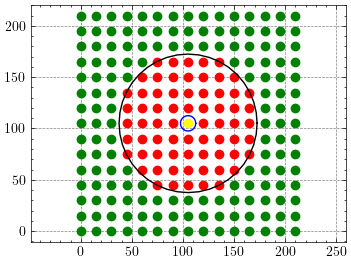

In [3]:
# NOTE: Units are mm, N, s

# Geometrical params
n1_blocks = 15
n2_blocks = 15
spacing = 15.0  # mm
hinge_length = 0.15 * spacing
initial_angle = 20 * jnp.pi / 180

# choose the limits of the excited blocks
x0, y0 = n1_blocks // 2 * spacing, n2_blocks // 2 * spacing
r0 = spacing / 2
N = 25
excited_blocks_limits = [
    [r0 * jnp.cos(2 * jnp.pi * k / N) + x0, r0 * jnp.sin(2 * jnp.pi * k / N) + y0]
    for k in range(N + 1)
]

# choose the limits of the shielding cloak blocks
r1 = 4.5 * spacing  # 3.8
N = 40
shielding_cloak_limits = [
    [r1 * jnp.cos(2 * jnp.pi * k / N) + x0, r1 * jnp.sin(2 * jnp.pi * k / N) + y0]
    for k in range(N + 1)
]

# Mechanical params
k_stretch = 120.0  # stretching stiffness 120. N/mm
k_shear = 1.19  # shearing stiffness 1.19 N/mm
k_rot = 1.50  # rotational stiffness 1.50 Nmm
density = 6.18e-9  # Mg/mm^2

damping_scaling = 1.0
damping = (
    0.0186
    * jnp.array(
        [
            2 * (0.36125 * density * spacing**2 * k_shear) ** 0.5,
            2 * (0.36125 * density * spacing**2 * k_shear) ** 0.5,
            2 * (0.02175026 * density * spacing**4 * k_rot) ** 0.5,
        ]
    )
    * damping_scaling
)

# boundary conditions
clamping_corners = True

# Forward input
amplitude = 0.3 * spacing
loading_rate = 2.0  # Hz
loading_angle = 0 * jnp.pi / 180
n_timepoints = 200
simulation_time = 2.0 / loading_rate  # s
optimization_name = "quads_shielding_multi_loading_source_3dp_pla_shims_4_loads"


# Forward problem
problem = ForwardProblem(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=hinge_length,
    shielding_cloak_limits=shielding_cloak_limits,
    excited_blocks_limits=excited_blocks_limits,
    horizontal_vertical_shifts_mg=None,
    initial_angle=initial_angle,
    k_stretch=k_stretch,
    k_shear=k_shear,
    k_rot=k_rot,
    density=density,
    k_contact=k_rot,
    damping=damping,
    min_angle=-15 * jnp.pi / 180,
    cutoff_angle=-10 * jnp.pi / 180,
    clamping_corners=clamping_corners,
    simulation_time=simulation_time,
    n_timepoints=n_timepoints,
    name=optimization_name,
)

problem.setup()
problem.plot_sketch()

In [4]:
design_value = problem.all_to_cloak_shifts(problem.horizontal_vertical_shifts_mg)

forward_input = ForwardInput(
    horizontal_shifts=design_value[0],
    vertical_shifts=design_value[1],
    amplitude=(amplitude, amplitude, amplitude, amplitude),
    loading_rate=(loading_rate, loading_rate, loading_rate, loading_rate),
    loading_angle=(
        0 * jnp.pi / 180,
        45 * jnp.pi / 180,
        90 * jnp.pi / 180,
        135 * jnp.pi / 180,
    ),
)

# Optimization
weights = (0.25, 0.25, 0.25, 0.25)
optimization = OptimizationProblem(
    forward_problem=problem,
    forward_input=forward_input,
    name=optimization_name,
    weights=weights,
)


problem_filename_prefix = f"quads_{optimization.forward_problem.n1_blocks}x{optimization.forward_problem.n2_blocks}_amplitude_{amplitude:.2f}_loading_rate_{loading_rate}_initial_angle_{initial_angle * 180 / jnp.pi:.1f}_clamping_corners_{clamping_corners}_damping_scaling_{damping_scaling}"
min_edge_length = 5
min_block_angle = 30
optimization_filename = f"opt_integrated_with_angle_{min_block_angle}_and_length_{min_edge_length}_constraints_{problem_filename_prefix}"

## Optimization

### Import most recent optimization object


In [4]:
optimization = OptimizationProblem.from_dict(
    load_data(f"../data/{optimization.name}/{optimization_filename}.pkl")
)

### Run optimization

In [ ]:
# optimization.run_optimization_nlopt(
#     initial_guess=(optimization.forward_input.horizontal_shifts,
#                    optimization.forward_input.vertical_shifts),
#     n_iterations=100,
#     min_block_angle=min_block_angle * jnp.pi / 180,
#     min_void_angle=0 * jnp.pi / 180,
#     min_edge_length=min_edge_length * 1.0,  # mm
#     max_time=12 * 60 * 60,  # 12 hours
# )

# save_data(
#     f"../data/{optimization.name}/{optimization_filename}.pkl",
#     optimization.to_dict(),  # Optimization problem
# )


## Plots

### Import most recent optimization object


In [5]:
optimization = OptimizationProblem.from_dict(
    load_data(
        f"../data/{optimization.name}/{optimization_filename}.pkl",
    )
)
optimization.setup_objective()

Setup intact case dynamics
Setup the solver of the shielding cloak dynamics


### Objective iterations


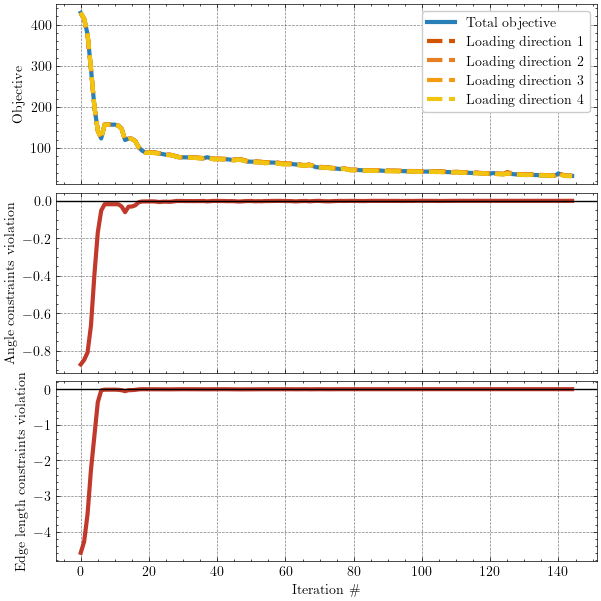

In [ ]:
plt.close("all")
fig, axes = plot_objective_and_constraints_iterations(
    optimization=optimization,
    figsize=(6, 6),
    optimization_filename=optimization_filename,
)

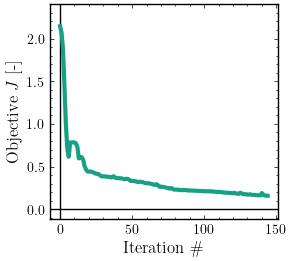

In [ ]:
plt.close("all")
fig, axes = plot_objective_iterations(
    optimization=optimization,
    figsize=(2.9, 2.6),
    optimization_filename=optimization_filename,
    fontsize=12,
    ticksize=10,
    linewidth=3,
    markersize=0,
    ylim=(None, 2.4),
)

### Plot designs


In [ ]:
plt.ioff()
for solution_data, label in zip(
    [
        optimization.forward_problem.solution_data["mg"],
        optimization.forward_problem.solution_data["opcg"][0],
    ],
    ["reference", "cloaked"],
):
    fig, axes = plot_geometry(
        block_centroids=solution_data.block_centroids,
        centroid_node_vectors=solution_data.centroid_node_vectors,
        bond_connectivity=solution_data.bond_connectivity,
        figsize=(4, 4),
    )
    axes.axis("off")
    fig.savefig(
        f"../out/{optimization.name}/{optimization_filename}/{label}_geometry.png",
        dpi=300,
        transparent=True,
    )
    plt.close(fig)
plt.ion()

In [ ]:
# More designs
plt.ioff()
for i, _design_value in enumerate(optimization.design_values):
    fig, axes = plot_geometry(
        block_centroids=optimization.forward_problem.cloaked_geometry.block_centroids(
            *optimization.forward_problem.cloak_to_all_shifts(_design_value)
        ),
        centroid_node_vectors=optimization.forward_problem.cloaked_geometry.centroid_node_vectors(
            *optimization.forward_problem.cloak_to_all_shifts(_design_value)
        ),
        bond_connectivity=optimization.forward_problem.cloaked_geometry.bond_connectivity(),
        figsize=(4, 4),
    )
    axes.axis("off")
    out_path = Path(
        f"../out/{optimization.name}/{optimization_filename}/designs/design_{i:03d}.png"
    )
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(out_path), dpi=300, transparent=True)
    plt.close(fig)
plt.ion()

### Plot designs and objectives

In [ ]:
from tqdm import tqdm

plt.close("all")
plt.ioff()
for i in tqdm(
    range(len(optimization.design_values)), desc="Plotting designs and objectives"
):
    fig, axes = plot_design_and_objective(
        optimization=optimization,
        iteration=i,
        figsize=(10, 4.2),
        fontsize=18,
        ticksize=16,
    )
    out_path = Path(
        f"../out/{optimization.name}/{optimization_filename}/designs_and_objectives/design_{i:03d}_objective.png"
    )
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(out_path), dpi=300)
    plt.close(fig)
plt.ion()

### Disturbance (error: "loaded - motionless" in surronding area)

In [ ]:
plt.close("all")
generate_delta_difference(
    solution_data=optimization.forward_problem.solution_data["ig"],
    mgIDs_surronding_area=problem.mgIDs_surronding_area,
    spacing=spacing,
    title="Disturbance in surronding area",
    solution_data_opcg=optimization.forward_problem.solution_data["opcg"],
    out_filename=f"../out/{optimization.name}/{optimization_filename}/delta_difference_opcg",
    sub_title=[f"Loading angle {angle}" for angle in [0, 45, 90, 135]],
    figsize=(6, 3),
)

In [ ]:
plt.close("all")
generate_delta_difference_column(
    solution_data=optimization.forward_problem.solution_data["ig"],
    mgIDs_surronding_area=problem.mgIDs_surronding_area,
    spacing=spacing,
    title="Disturbance in surronding area",
    solution_data_opcg=optimization.forward_problem.solution_data["opcg"],
    out_filename=f"../out/{optimization.name}/{optimization_filename}/delta_difference_opcg_several_plots",
    sub_title=[f"Loading angle {angle}" for angle in [0, 45, 90, 135]],
    figsize=(6, 6),
)

### Response animation: Optimized cloaked geometry

In [ ]:
plt.close("all")
xlim, ylim = problem.cloaked_geometry.get_xy_limits(
    *problem.horizontal_vertical_shifts_mg
) + 0.5 * problem.cloaked_geometry.spacing * jnp.array([-2, 2])

generate_several_animations(
    optimization.forward_problem.solution_data["opcg"],
    field="u",
    out_filename=f"../out/{optimization.name}/{optimization_filename}/{problem_filename_prefix}_optimized_shielding_cloaks",
    row_or_column="row",
    xlim=xlim,
    ylim=ylim,
    fps=30,
    dpi=300,
    cmap="inferno",
    frame_range=range(
        0, len(optimization.forward_problem.solution_data["opcg"][0].timepoints), 2
    ),
    figsize=(4.1 * len(optimization.forward_problem.solution_data["opcg"]), 4),
    legend_label="Displacement [mm]",
    axis=False,
)

In [ ]:
plt.close("all")
xlim, ylim = problem.cloaked_geometry.get_xy_limits(
    *problem.horizontal_vertical_shifts_mg
) + 0.5 * problem.cloaked_geometry.spacing * jnp.array([-2, 2])

generate_several_animations(
    optimization.forward_problem.solution_data["ig"],
    field="u",
    out_filename=f"../out/{optimization.name}/{optimization_filename}/{problem_filename_prefix}_initial_guess_shielding_cloaks",
    row_or_column="row",
    xlim=xlim,
    ylim=ylim,
    fps=30,
    dpi=300,
    cmap="inferno",
    frame_range=range(
        0, len(optimization.forward_problem.solution_data["ig"][0].timepoints), 2
    ),
    figsize=(4.1 * len(optimization.forward_problem.solution_data["ig"]), 4),
    legend_label="Displacement [mm]",
    axis=False,
)

In [ ]:
plt.close("all")
xlim, ylim = problem.cloaked_geometry.get_xy_limits(
    *problem.horizontal_vertical_shifts_mg
) + 0.5 * problem.cloaked_geometry.spacing * jnp.array([[-2, 2], [-3, 3]])

solutions_data = [
    optimization.forward_problem.solution_data["ig"],
    optimization.forward_problem.solution_data["opcg"],
]
generate_several_animations(
    solutions_data,
    field="u",
    out_filename=f"../out/{optimization.name}/{optimization_filename}/{problem_filename_prefix}_both_shielding_cloaks",
    row_or_column="both",
    xlim=xlim,
    ylim=ylim,
    fps=30,
    dpi=300,
    cmap="inferno",
    frame_range=range(0, len(solutions_data[0][0].timepoints), 2),
    figsize=(4.1 * len(solutions_data[0]), 4 * len(solutions_data)),
    legend_label="Displacement [mm]",
    axis=False,
)

## Assessing robustness wrt loading angle

In [ ]:
# def initialize_df_robustness_loading_angle():
#     data = {
#         "Amplitude": [],
#         "Loading_rate": [],
#         "Objective_ig": [],
#         "Objective_opcg": [],
#         "Ratio_objective": [],
#         "Min_edge_length": [],
#     }
#     df_results = pd.DataFrame(data=data)
#     save_data(
#         f"../data/{optimization.name}/robustness/df_robustness_loading_angle.pkl",
#         df_results,
#     )


# def assess_robustness(
#     amplitude: float,
#     loading_rate: float,
#     loading_angle_in_deg: float,
#     optimization: OptimizationProblem,
#     min_edge_length: int,
# ):
#     # convert loading_angle in radians
#     loading_angle = loading_angle_in_deg * jnp.pi / 180
#     # setup the filename
#     problem_filename_prefix = f"quads_{optimization.forward_problem.n1_blocks}x{optimization.forward_problem.n2_blocks}_amplitude_{amplitude:.2f}_loadingrate_{loading_rate:.2f}_loadingangle_{loading_angle:.2f}"
#     optimization_filename = f"opt_integrated_with_angle_{min_block_angle}_and_length_{min_edge_length}_constraints_{problem_filename_prefix}"

#     # get the solutionData for the inital design variables
#     solution_data_ig = optimization.forward_problem.solve(
#         optimization.design_values[0], amplitude, loading_rate, loading_angle
#     )
#     save_data(
#         f"../data/{optimization.name}/robustness/{optimization_filename}/initial_design_variables/{problem_filename_prefix}.pkl",
#         solution_data_ig,
#     )

#     # get the solutionData for the optimizated design variables
#     solution_data_opcg = optimization.forward_problem.solve(
#         optimization.design_values[-1], amplitude, loading_rate, loading_angle
#     )
#     save_data(
#         f"../data/{optimization.name}/robustness/{optimization_filename}/optimized_design_variables/{problem_filename_prefix}.pkl",
#         solution_data_opcg,
#     )

#     # compute the individual objective
#     objective_ig = compute_individual_objective(solution_data_ig, optimization)
#     objective_opcg = compute_individual_objective(solution_data_opcg, optimization)

#     # add the result to the Dataframe
#     df_results = load_data(
#         f"../data/{optimization.name}/robustness/df_robustness_loading_angle.pkl"
#     )
#     new_row = {
#         "Amplitude": amplitude,
#         "Loading_rate": loading_rate,
#         "Loading_angle_in_deg": loading_angle_in_deg,
#         "Objective_ig": objective_ig,
#         "Objective_opcg": objective_opcg,
#         "Ratio_objective": objective_opcg / objective_ig,
#         "Min_edge_length": min_edge_length,
#     }
#     df_results = df_results._append(new_row, ignore_index=True)
#     save_data(
#         f"../data/{optimization.name}/robustness/df_robustness_loading_angle.pkl",
#         df_results,
#     )

In [8]:
# choose the min_edge_length parameter
min_edge_length = 5

# load the optimization problem
optimization = OptimizationProblem.from_dict(
    load_data(
        f"../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads/opt_integrated_with_angle_30_and_length_{min_edge_length}_constraints_quads_15x15_amplitude_4.50_loading_rate_2.0_initial_angle_20.0_clamping_corners_True_damping_scaling_1.0.pkl"
    )
)
optimization.forward_problem.setup()
optimization_filename = f"opt_integrated_with_angle_{min_block_angle}_and_length_{min_edge_length}_constraints_{problem_filename_prefix}"
print("optimization_filename: ", optimization_filename)

Setup intact case dynamics
Setup the solver of the shielding cloak dynamics
optimization_filename:  opt_integrated_with_angle_30_and_length_5_constraints_quads_15x15_amplitude_4.50_loading_rate_2.0_initial_angle_20.0_clamping_corners_True_damping_scaling_1.0


In [ ]:
# loading_angle_in_deg_array = jnp.arange(0, 185, 5)
# loading_rate_array = jnp.linspace(2, 30, 29 * 2 - 1)
# for _loading_rate in loading_rate_array:
#     for loading_angle_in_deg in loading_angle_in_deg_array:
#         print("loading_rate: ", _loading_rate)
#         print("loading_angle_in_deg: ", loading_angle_in_deg)
#         start_time = time.time()
#         assess_robustness(
#             amplitude=amplitude,
#             loading_rate=_loading_rate * 1.0,
#             loading_angle_in_deg=loading_angle_in_deg,
#             optimization=optimization,
#             min_edge_length=min_edge_length,
#         )
#         end_time = time.time()
#         print(f"Time taken: {end_time - start_time:.2f} seconds")

In [9]:
df_results = load_data(
    f"../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads/{optimization_filename}/df_robustness_loading_angle_2-30Hz.pkl"
)

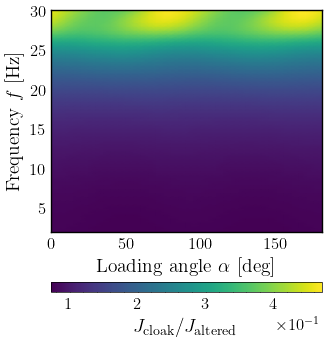

In [ ]:
plt.close("all")

min_edge_length_list = [5.0]
N = len(min_edge_length_list)
fig, axs = plt.subplots(figsize=(3.25, 3.4), constrained_layout=True)
# fig.suptitle('Ratio disturbance between optimized cloak and initial cloak depending on the loading parameters')
list_v_min_v_max = []
data_slice = df_results[df_results.Min_edge_length == 5.0].copy()
data_slice["Loading_rate"] = data_slice["Loading_rate"].astype(float)
data_slice["Loading_angle_in_deg"] = data_slice["Loading_angle_in_deg"].astype(int)
# Only select angles between 0 and 180
data_slice = data_slice[
    (data_slice.Loading_angle_in_deg >= 0) & (data_slice.Loading_angle_in_deg <= 180)
]
data_slice["Ratio_objective"] = data_slice["Ratio_objective"].astype(float)
df_pivot = data_slice.pivot(
    index="Loading_rate", columns="Loading_angle_in_deg", values="Ratio_objective"
)

# Get the x, y, and z values
x = df_pivot.columns.values
y = df_pivot.index.values
z = df_pivot.values

# Create the meshgrid
X, Y = jnp.meshgrid(x, y)

# Plot with pcolormesh
axs.pcolormesh(X, Y, z, shading="gouraud", cmap="viridis")
axs.set_xlabel(r"Loading angle $\alpha$ [deg]", fontsize=14)
axs.set_ylabel(r"Frequency $f$ [Hz]", fontsize=14)
# axs.set_title(f'{min_edge_length} as min edge length')
axs.tick_params(labelsize=12)
# Spines 1pt thick
for spine in axs.spines.values():
    spine.set_linewidth(1)

vmin = z.min()
vmax = z.max()

cb = fig.colorbar(
    cm.ScalarMappable(cmap="viridis", norm=colors.Normalize(vmin=vmin, vmax=vmax)),
    pad=0.02,
    aspect=25,
    ax=axs,
    location="bottom",
)
cb.set_label(r"$J_\text{cloak}/J_\text{altered}$", fontsize=14)
cb.ax.tick_params(labelsize=12)
cb.ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
cb.ax.xaxis.get_offset_text().set_fontsize(12)
# cb.ax.xaxis.get_offset_text().set_position((4., 0))

out_path = Path(
    f"../out/{optimization.name}/{optimization_filename}/robustness_objective_ratio_frequency_vs_loading_angle_2-30Hz.png"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(str(out_path), dpi=300)

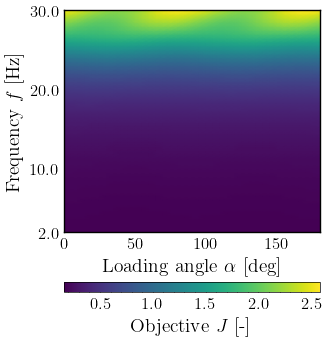

In [11]:
plt.close("all")

min_edge_length_list = [5.0]
N = len(min_edge_length_list)
fig, axs = plt.subplots(figsize=(3.25, 3.4), constrained_layout=True)
# fig.suptitle('Ratio disturbance between optimized cloak and initial cloak depending on the loading parameters')
list_v_min_v_max = []
data_slice = df_results[df_results.Min_edge_length == 5.0].copy()
data_slice["Loading_rate"] = data_slice["Loading_rate"].astype(float)
data_slice["Loading_angle_in_deg"] = data_slice["Loading_angle_in_deg"].astype(int)
# Only select angles between 0 and 180
data_slice = data_slice[
    (data_slice.Loading_angle_in_deg >= 0) & (data_slice.Loading_angle_in_deg <= 180)
]
data_slice["Objective_opcg"] = data_slice["Objective_opcg"].astype(float)
df_pivot = data_slice.pivot(
    index="Loading_rate", columns="Loading_angle_in_deg", values="Objective_opcg"
)

# Get the x, y, and z values
x = df_pivot.columns.values
y = df_pivot.index.values
z = df_pivot.values / optimization.forward_problem.n_timepoints

# Create the meshgrid
X, Y = jnp.meshgrid(x, y)

# Plot with pcolormesh
axs.pcolormesh(X, Y, z, shading="gouraud", cmap="viridis")
axs.set_xlabel(r"Loading angle $\alpha$ [deg]", fontsize=14)
axs.set_ylabel(r"Frequency $f$ [Hz]", fontsize=14)
# axs.set_title(f'{min_edge_length} as min edge length')
axs.tick_params(labelsize=12)
# Spines 1pt thick
for spine in axs.spines.values():
    spine.set_linewidth(1)

vmin = z.min()
vmax = z.max()

# Add 1 decimal figure to ytick labels
axs.set_yticks([2.0, 10.0, 20.0, 30.0])
axs.set_yticklabels([f"{tick:.1f}" for tick in axs.get_yticks()])

cb = fig.colorbar(
    cm.ScalarMappable(cmap="viridis", norm=colors.Normalize(vmin=vmin, vmax=vmax)),
    pad=0.02,
    aspect=25,
    ax=axs,
    location="bottom",
)
cb.set_label(r"Objective $J$ [-]", fontsize=14)
cb.ax.tick_params(labelsize=12)
# cb.ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
# cb.ax.xaxis.get_offset_text().set_fontsize(12)
# cb.ax.xaxis.get_offset_text().set_position((4., 0))

# out_path = Path(
#     f"../out/{optimization.name}/{optimization_filename}/robustness_frequency_vs_loading_angle_2-30Hz.png"
# )
# out_path.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(str(out_path), dpi=300)